# Imports

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from scipy.stats import levy_stable
import seaborn as sns
import scipy.stats as stats
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import adfuller

# First Steps

In [2]:
ticker = "BTC-USD"

# Récupération des données depuis le début (2010-07-17 = première data Yahoo)
btc = yf.download(
    ticker,
    start="2010-07-17",
    interval="1d",
    auto_adjust=False,
    progress=False
)

In [3]:
btc = btc.dropna()
btc.index = pd.to_datetime(btc.index)

In [4]:
btc.to_csv("bitcoin_full_history.csv")

In [281]:
btc.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2014-09-17,457.334015,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,398.821014,412.425995,393.181000,408.084991,26580100


In [5]:
btc.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2026-03-12,70493.460938,70493.460938,70775.828125,69230.156250,70209.765625,40871848129
2026-03-13,70968.265625,70968.265625,73927.328125,70410.726562,70497.046875,61167226505
2026-03-14,71214.625000,71214.625000,71291.203125,70339.585938,70965.382812,22283546496
2026-03-15,72789.914062,72789.914062,73173.007812,70882.421875,71213.679688,27991268669
2026-03-16,73177.554688,73177.554688,74363.125000,72323.093750,72820.781250,40772259840


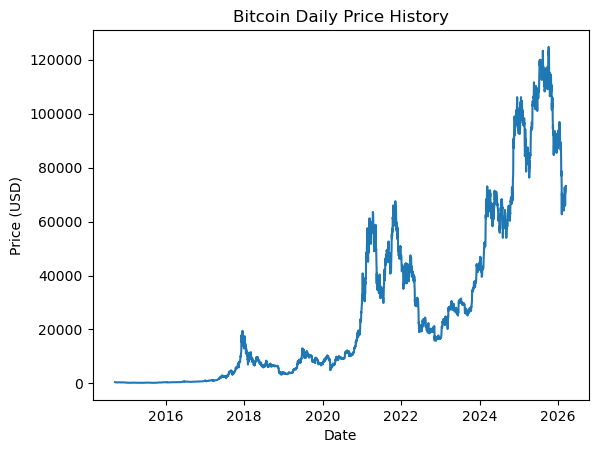

In [6]:
plt.figure()
plt.plot(btc["Close"])
plt.title("Bitcoin Daily Price History")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

In [8]:
btc["log_return"] = (btc["Close"] / btc["Close"].shift(1)).apply(lambda x: np.log(x))
btc["return"] = btc["Close"].pct_change()

<Axes: >

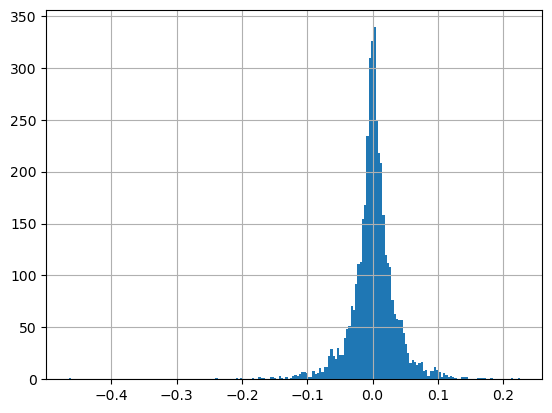

In [9]:
btc['log_return'].hist(bins=200)

In [286]:
r = btc["log_return"].dropna()

print("Mean:", r.mean())
print("Std:", r.std())
print("Skewness:", skew(r))
print("Excess Kurtosis:", kurtosis(r))

Mean: 0.001204064451636018
Std: 0.03539349499422866
Skewness: -0.7094384924453297
Excess Kurtosis: 11.701681079517659


In [287]:
print("Mean:", btc['return'].mean())
print("Std:", btc['return'].std())
print("Skewness:", skew(btc['return'].dropna()))
print("Excess Kurtosis:", kurtosis(btc['return'].dropna()))

Mean: 0.0018274169196558054
Std: 0.03515849414615101
Skewness: -0.10047749636725478
Excess Kurtosis: 7.832600400848056


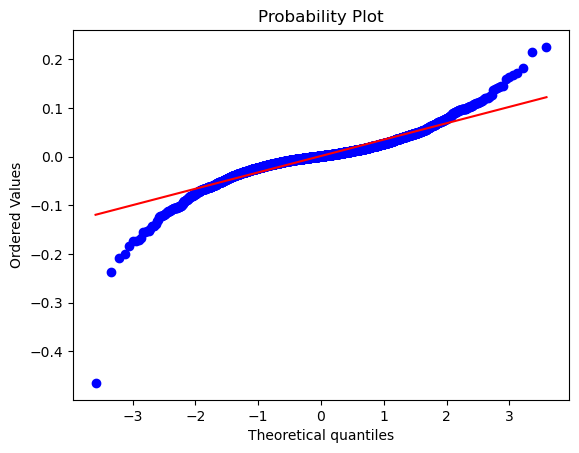

In [288]:
stats.probplot(r, dist="norm", plot=plt)
plt.show()

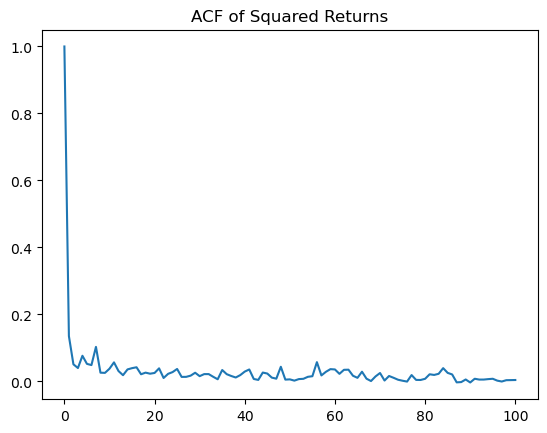

In [289]:
btc["vol_proxy"] = r**2

acf_vol = acf(btc["vol_proxy"].dropna(), nlags=100)

plt.figure()
plt.plot(acf_vol)
plt.title("ACF of Squared Returns")
plt.show()

<Axes: >

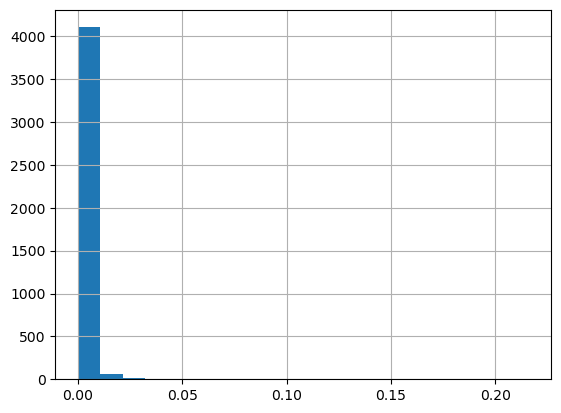

In [290]:
btc["vol_proxy"].hist(bins=20)

<Axes: xlabel='Date'>

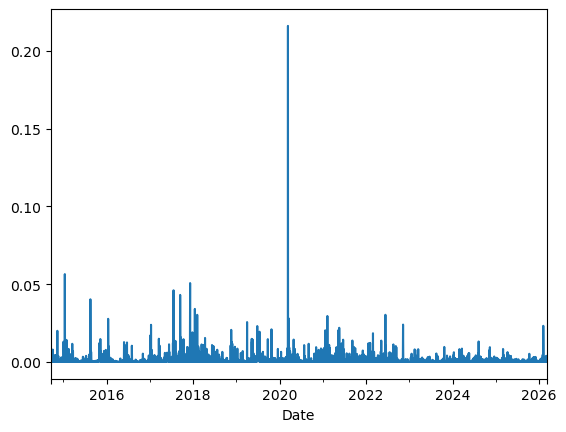

In [291]:
btc["vol_proxy"].plot()

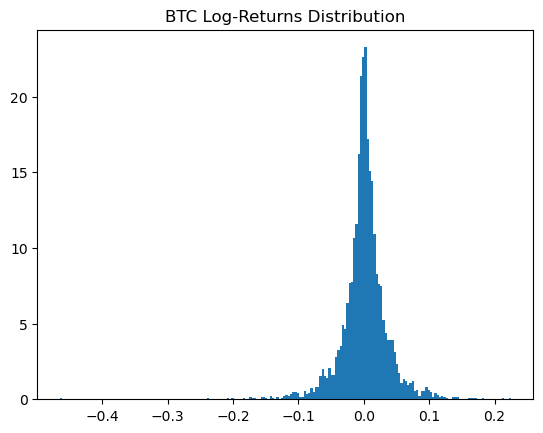

In [292]:
plt.figure()
plt.hist(r, bins=200, density=True)
plt.title("BTC Log-Returns Distribution")
plt.show()

In [293]:
print("Description of log returns : ", btc['log_return'].describe())

Description of log returns :  count    4188.000000
mean        0.001204
std         0.035393
min        -0.464730
25%        -0.012663
50%         0.001088
75%         0.015872
max         0.225119
Name: log_return, dtype: float64


In [294]:
print('Simple returns descriptions', btc['return'].describe())

Simple returns descriptions count    4188.000000
mean        0.001827
std         0.035158
min        -0.371695
25%        -0.012583
50%         0.001088
75%         0.015999
max         0.252472
Name: return, dtype: float64


# Heavy Taildness

In [295]:
def hill_estimator(data, k=1000):
    x = np.sort(np.abs(data))
    x = x[-k:]
    x_k = x[0]
    hill = (1/k) * np.sum(np.log(x/x_k))
    return 1/hill

alpha = hill_estimator(r.values, k=1000)
print("Tail index alpha:", alpha)

Tail index alpha: 1.8605916240225921


# Market Efficiency

In [296]:
def robust_acf_test(r, lag=1, q=8):
    T = len(r)
    m = T//q
    
    acfs = []
    
    for i in range(q):
        block = r[i*m:(i+1)*m]
        acf_val = np.corrcoef(block[:-lag], block[lag:])[0,1]
        acfs.append(acf_val)
    
    acfs = np.array(acfs)
    
    t_stat = acfs.mean() / (acfs.std()/np.sqrt(q))
    
    return t_stat

print("Robust ACF t-stat:", robust_acf_test(r.values))

Robust ACF t-stat: -1.919855123185776


## Volatility Clustering

In [297]:
print("Robust Vol Clustering:",
      robust_acf_test((r**2).values))

Robust Vol Clustering: 4.532070315129918


In [298]:
jb_stat, jb_p = jarque_bera(r)

print("Jarque-Bera stat:", jb_stat)
print("p-value:", jb_p)

Jarque-Bera stat: 24245.47532138145
p-value: 0.0


In [299]:
arch_test = het_arch(r)

print("ARCH stat:", arch_test[0])
print("p-value:", arch_test[1])

ARCH stat: 146.03898066055774
p-value: 2.4304988907451013e-26


In [300]:
adf = adfuller(r)

print("ADF stat:", adf[0])
print("p-value:", adf[1])

ADF stat: -19.666587317446883
p-value: 0.0


# First Framework : A Test

In [423]:
halving_dates = pd.to_datetime([
    "2012-11-28",
    "2016-07-09",
    "2020-05-11",
    "2024-04-20"
])

def halving_effect(dates, gamma=0.01, window=800):
    """
    Halving effect with temporary exponential decay.
    
    Parameters
    ----------
    dates : pd.DatetimeIndex
    gamma : float
        Speed of decay (higher = faster decay)
    window : int
        Maximum number of days during which the halving has an effect
    
    Returns
    -------
    H : np.array
        Time-varying halving effect
    """
    
    H = np.zeros(len(dates))
    
    for tau in halving_dates:
        
        dt = (dates - tau).days
        
        contrib = np.where(
            (dt > 0) & (dt < window),
            np.exp(-gamma * dt),
            0
        )
        
        H += contrib
    
    return H

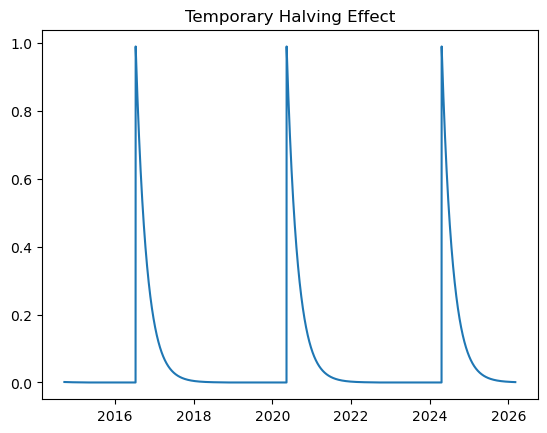

In [424]:
btc["H_temp"] = halving_effect(btc.index)

plt.plot(btc.index, btc["H_temp"])
plt.title("Temporary Halving Effect")
plt.show()

In [425]:
def stable_noise(alpha, size, dt):
    return levy_stable.rvs(alpha,
                           0,
                           scale=dt**(1/alpha),
                           size=size)

In [426]:
def simulate_crypto_model(
    T=6000,
    dt=1/365,
    S0=500,
    v0=0.04,
    alpha=1.86,
    mu0=0.04,
    beta=0.05,
    kappa=2,
    theta0=0.04,
    eta=0.03,
    xi=0.5,
    gamma=0.002
):
    
    dates = pd.date_range("2010-07-17", periods=T)
    
    H = halving_effect(dates, gamma)
    
    S = np.zeros(T)
    v = np.zeros(T)
    
    S[0] = S0
    v[0] = v0
    
    for t in range(1, T):
        
        dL = stable_noise(alpha,1,dt)
        dB = np.sqrt(dt)*np.random.randn()
        
        theta_t = theta0 + eta*H[t]
        
        v[t] = (
            v[t-1]
            + kappa*(theta_t - v[t-1])*dt
            + xi*np.sqrt(v[t-1])*dB
        )
        
        v[t] = np.maximum(v[t],1e-8)
        
        mu_t = mu0 + beta*H[t]
        
        S[t] = (
            S[t-1]
            * np.exp(
                mu_t*dt
                + np.sqrt(v[t-1])*dL
            )
        )
        
    return dates,S,v

/var/folders/nk/kpj6413n2lj1cln9c1z0_pj80000gn/T/ipykernel_1830/3920486491.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S[t] = (


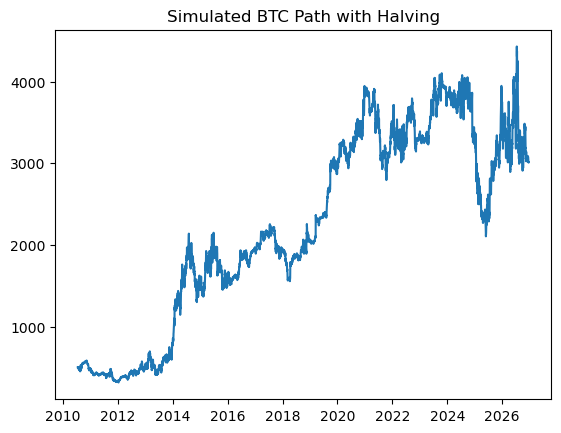

In [427]:
dates,S,v = simulate_crypto_model()

plt.figure()
plt.plot(dates,S)
plt.title("Simulated BTC Path with Halving")
plt.show()

In [428]:
r_sim = np.diff(np.log(S))

from scipy.stats import kurtosis

print("Simulated Kurtosis:",
      kurtosis(r_sim))

Simulated Kurtosis: 8.105874491010352


In [429]:
print("Simulated alpha:",
      hill_estimator(r_sim))

Simulated alpha: 2.316939297446383


In [430]:
print("Simulated clustering:",
      robust_acf_test(r_sim**2))

Simulated clustering: 1.7765289511954168


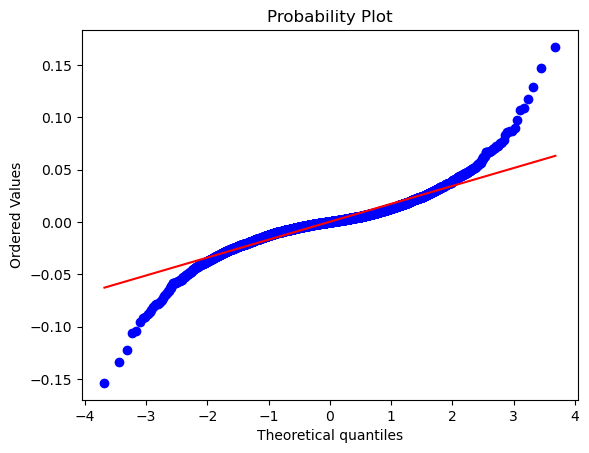

In [431]:
stats.probplot(r_sim, dist="norm", plot=plt)
plt.show()

## Some multiple trajectories

In [432]:
M = 20  # nombre de trajectoires

paths = []

for i in range(M):
    
    dates, S, v = simulate_crypto_model()
    paths.append(S)

paths = np.array(paths)

/var/folders/nk/kpj6413n2lj1cln9c1z0_pj80000gn/T/ipykernel_1830/3920486491.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S[t] = (


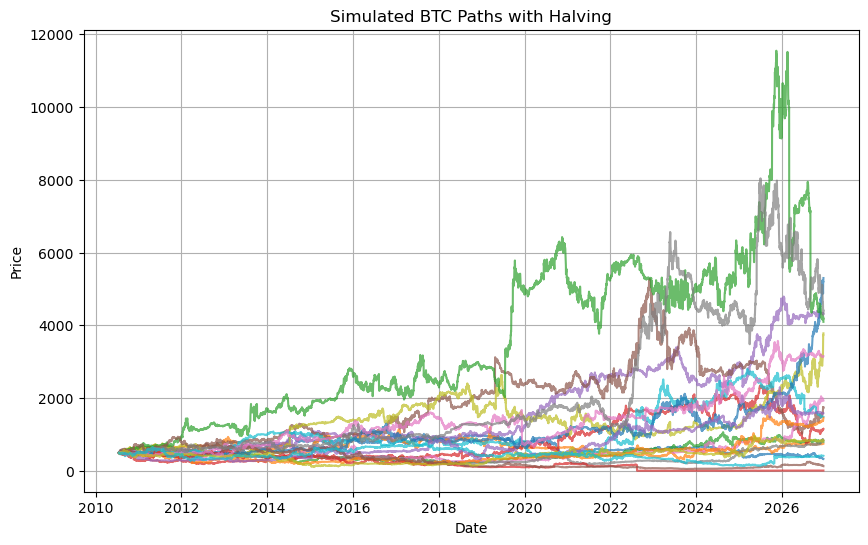

In [435]:
plt.figure(figsize=(10,6))

for i in range(M):
    plt.plot(dates, paths[i], alpha=0.7)

plt.title("Simulated BTC Paths with Halving")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

plt.show()

# Beta Calibration (Does not work)

In [309]:
halving_dates = pd.to_datetime([
    "2012-11-28",
    "2016-07-09",
    "2020-05-11",
    "2024-04-20"
])

btc["H"] = 0

gamma = 0.002

for tau in halving_dates:
    
    dt = (btc.index - tau).days
    
    contrib = np.where(dt > 0,
                       1 - np.exp(-gamma*dt),
                       0)
    
    btc["H"] += contrib

In [310]:
import statsmodels.api as sm

df = btc.dropna()

X = sm.add_constant(df["H"])
y = df["log_return"]

model = sm.QuantReg(y, X)

res = model.fit(q=0.5)

print(res.summary())

                         QuantReg Regression Results                          
Dep. Variable:             log_return   Pseudo R-squared:            0.0008177
Model:                       QuantReg   Bandwidth:                    0.006476
Method:                 Least Squares   Sparsity:                      0.04510
Date:                Fri, 06 Mar 2026   No. Observations:                 4188
Time:                        09:57:41   Df Residuals:                     4186
                                        Df Model:                            1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0030      0.001      3.267      0.001       0.001       0.005
H             -0.0009      0.000     -2.226      0.026      -0.002      -0.000


In [311]:
beta_hat = res.params["H"]

beta_model = beta_hat * 365

In [312]:
beta_model

np.float64(-0.3239384924147171)

/var/folders/nk/kpj6413n2lj1cln9c1z0_pj80000gn/T/ipykernel_1830/1944644040.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S[t] = (


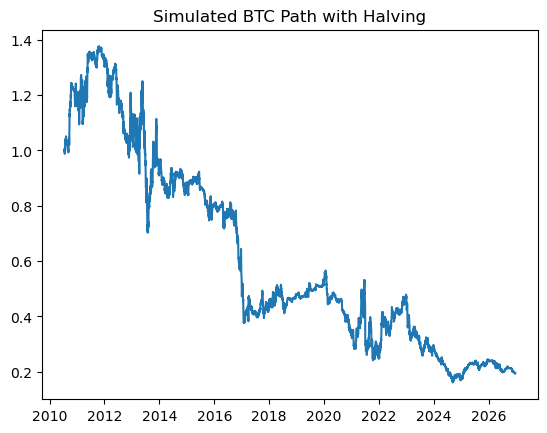

In [313]:
dates, S, v = simulate_crypto_model(
    beta=beta_model
)

plt.figure()
plt.plot(dates,S)
plt.title("Simulated BTC Path with Halving")
plt.show()

# Correlation Data Analysis

In [10]:
tickers = {
    "BTC": "BTC-USD",
    "GOLD": "GC=F",
    "SP500": "^GSPC",
    "NASDAQ": "^IXIC", 
    "US 10Y" : "^TNX"
}

data = yf.download(
    list(tickers.values()),
    start="2010-07-17",
    interval="1d",
    progress=False
)["Close"]

data.columns = tickers.keys()

data = data.dropna()

/var/folders/nk/kpj6413n2lj1cln9c1z0_pj80000gn/T/ipykernel_2649/369581056.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(


In [11]:
returns = np.log(data/data.shift(1)).dropna()

In [14]:
window = 90

corr_btc_gold = returns["BTC"].rolling(window).corr(returns["GOLD"])
corr_btc_sp = returns["BTC"].rolling(window).corr(returns["SP500"])
corr_btc_nasdaq = returns["BTC"].rolling(window).corr(returns["NASDAQ"])
corr_btc_rates = returns['BTC'].rolling(window).corr(returns['US 10Y'])

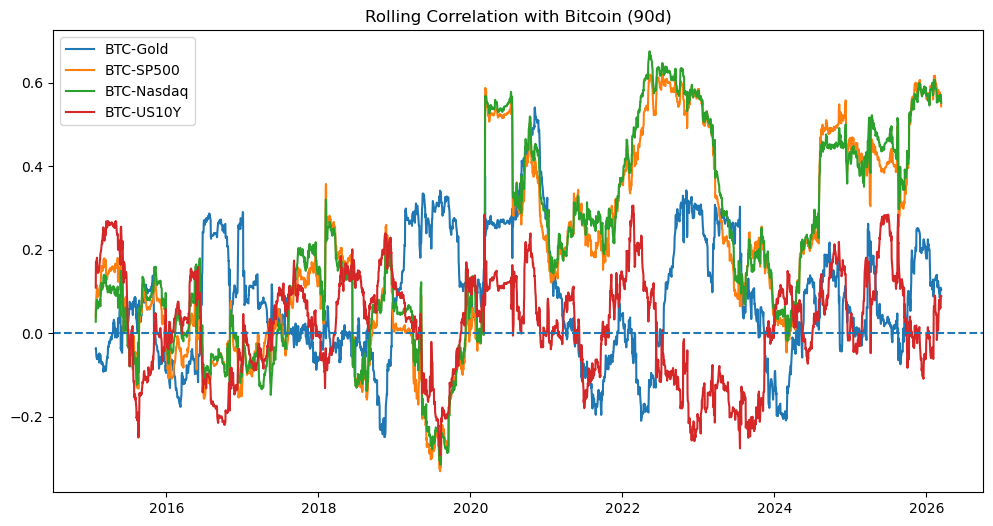

In [16]:
plt.figure(figsize=(12,6))

plt.plot(corr_btc_gold, label="BTC-Gold")
plt.plot(corr_btc_sp, label="BTC-SP500")
plt.plot(corr_btc_nasdaq, label="BTC-Nasdaq")
plt.plot(corr_btc_rates, label="BTC-US10Y")

plt.axhline(0, linestyle="--")
plt.legend()
plt.title("Rolling Correlation with Bitcoin (90d)")
plt.show()

In [17]:
returns["year"] = returns.index.year

print(returns.groupby("year").corr()["BTC"])

year        
2014  BTC       1.000000
      GOLD     -0.058700
      SP500    -0.090978
      NASDAQ   -0.035095
      US 10Y    0.016229
                  ...   
2026  BTC       1.000000
      GOLD      0.075248
      SP500     0.580601
      NASDAQ    0.579585
      US 10Y    0.170466
Name: BTC, Length: 65, dtype: float64


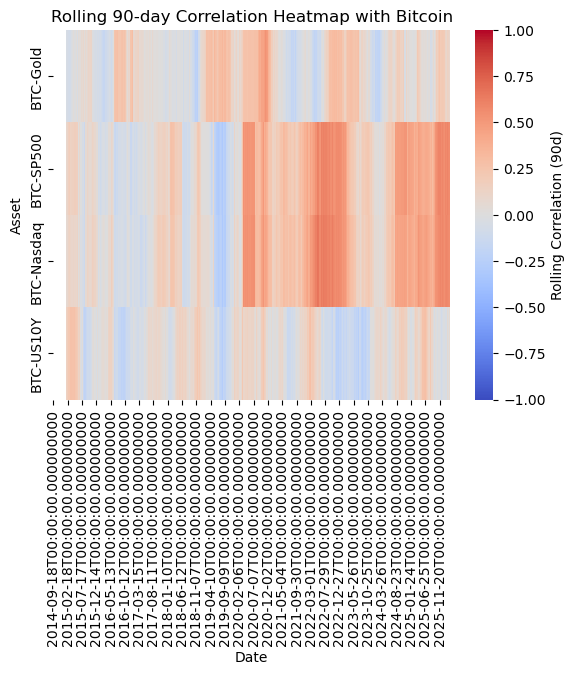

In [20]:
rolling_corrs = pd.DataFrame({
    "BTC-Gold": returns["BTC"].rolling(window).corr(returns["GOLD"]),
    "BTC-SP500": returns["BTC"].rolling(window).corr(returns["SP500"]),
    "BTC-Nasdaq": returns["BTC"].rolling(window).corr(returns["NASDAQ"]),
    "BTC-US10Y" : returns['BTC'].rolling(window).corr(returns['US 10Y'])
}, index=returns.index)

sns.heatmap(
    rolling_corrs.T,  # transpose pour que les actifs soient sur l'axe y
    cmap="coolwarm",
    vmin=-1, vmax=1,
    cbar_kws={"label": "Rolling Correlation (90d)"}
)

plt.title("Rolling 90-day Correlation Heatmap with Bitcoin")
plt.xlabel("Date")
plt.ylabel("Asset")
plt.show()

# Seconde modélisation : Fondamentale

In [320]:
# ----------------------
# Paramètres de simulation
# ----------------------
total_supply = 21_000_000
initial_reward = 50          # BTC/block
halving_blocks = 210_000
block_time = 10/60/24        # jours par block (~10 min)
T_days = 5000                # durée simulation (~13 ans)
dt = 1                       # pas journalier

# Adoption & demande
D0 = 10000                     # demande initiale arbitraire
phi = 0.0005                 # croissance adoption journalière
alpha_noise = 1.86            # heavy tail alpha

# Coût minage (floor)
C_floor = 5000               # prix plancher pour rentabilité

# k = facteur de rareté / conversion
k = 1e5

In [321]:
# ----------------------
# Générer l'offre cumulative
# ----------------------
def compute_supply(T_days, initial_reward=50, halving_blocks=210_000, block_time=10/60/24):
    B_t = np.arange(1, T_days+1) / block_time
    supply = np.zeros_like(B_t)
    for t, B in enumerate(B_t):
        halving_n = int(B // halving_blocks)
        reward = initial_reward / 2**halving_n
        blocks_in_current_halving = B - halving_n * halving_blocks
        supply[t] = np.sum([halving_blocks * (initial_reward / 2**i) for i in range(halving_n)]) \
                    + blocks_in_current_halving * reward
    supply = np.minimum(supply, total_supply)
    return supply

In [322]:
# ----------------------
# Générer la demande stochastique
# ----------------------
def simulate_demand(T_days, D0=1e6, phi=0.0005, alpha=1.86):
    D = np.zeros(T_days)
    D[0] = D0
    for t in range(1, T_days):
        growth = D[t-1]*phi
        shock = levy_stable.rvs(alpha, 0, scale=1e4)
        D[t] = max(D[t-1] + growth + shock, 0)
    return D

In [323]:
# ----------------------
# Prix comme équilibre offre/demande + plancher minage
# ----------------------
def compute_price(S_t, D_t, k=1e6, C_floor=5000):
    P_t = k * D_t / np.maximum(total_supply - S_t, 1e-8)
    P_t = np.maximum(P_t, C_floor)
    return P_t

In [324]:
# ----------------------
# Simulation complète
# ----------------------
supply = compute_supply(T_days)
demand = simulate_demand(T_days, D0, phi, alpha_noise)
price = compute_price(supply, demand, k, C_floor)

dates = pd.date_range(start="2010-07-17", periods=T_days)

df = pd.DataFrame({
    "Supply": supply,
    "Demand": demand,
    "Price": price
}, index=dates)

alpha_noise = 1.86
sigma_noise = 0.04  # ajustable pour volatilité journalière ~3%
price_stoch = np.zeros_like(price)
price_stoch[0] = 500  # prix initial réaliste en 2010

for t in range(1, len(price)):
    drift = (price[t] - price[t-1]) / price[t-1]
    shock = sigma_noise * levy_stable.rvs(alpha_noise, 0)
    price_stoch[t] = price_stoch[t-1] * np.exp(drift + shock)

# Ajouter au DataFrame pour visualisation
df["Price_Stoch"] = price_stoch

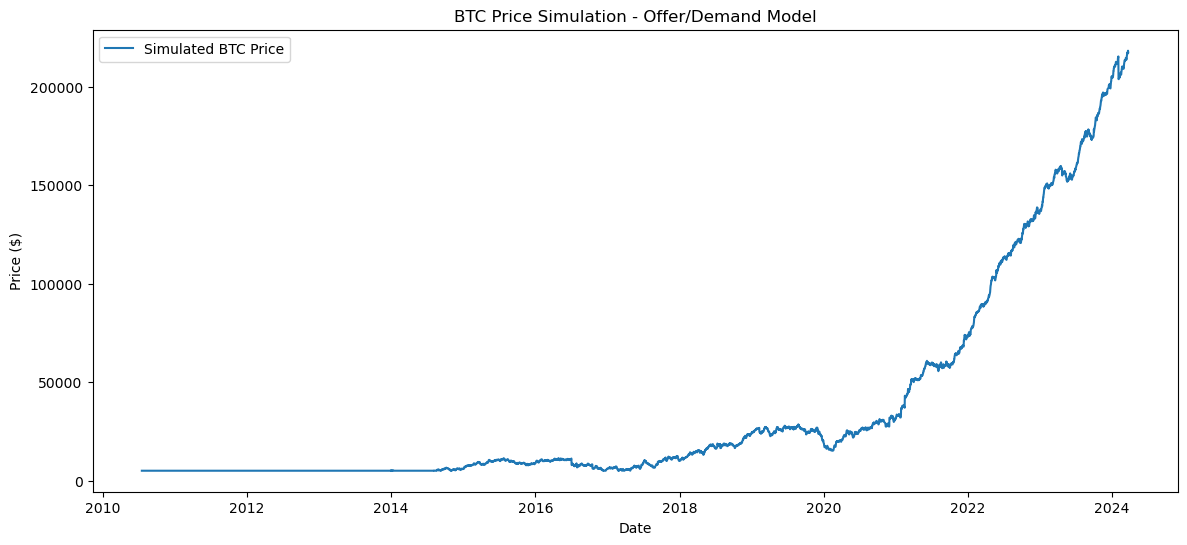

In [325]:
# ----------------------
# Visualisation
# ----------------------
plt.figure(figsize=(14,6))
plt.plot(df.index, df["Price"], label="Simulated BTC Price")
plt.title("BTC Price Simulation - Offer/Demand Model")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.legend()
plt.show()

In [326]:
df["log_return"] = np.log(df["Price"]/df["Price"].shift(1))
returns = df["log_return"].dropna()

# Skew, Kurtosis
from scipy.stats import skew, kurtosis

print("Skew:", skew(returns))
print("Kurtosis:", kurtosis(returns))

# Approximation tail index via Hill estimator
def hill_estimator(x, k=500):
    x = np.sort(np.abs(x))[-k:]
    return 1/np.mean(np.log(x/np.min(x)))

alpha_est = hill_estimator(returns.values, k=500)
print("Estimated alpha (tail index):", alpha_est)

Skew: -2.5161528151798565
Kurtosis: 58.00464857789519
Estimated alpha (tail index): 2.423489623674119


Si on définit le drift comme cette équation et qu'on intègre vol heston (CIR model) alors on a quelque chose de probant à mon avis

# Some Tests

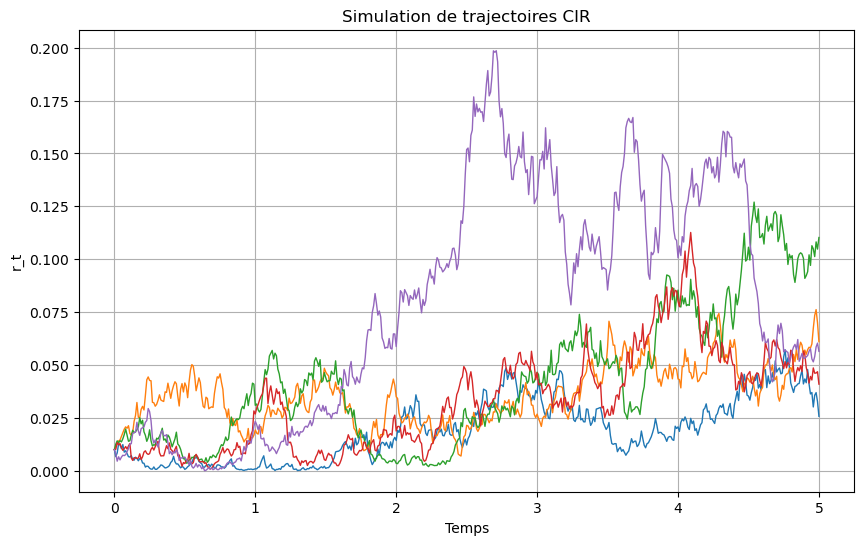

In [327]:
# Paramètres du modèle CIR
k = 0.5       # vitesse de réversion
theta = 0.05  # niveau moyen
sigma = 0.2   # volatilité
r0 = 0.01     # taux initial
T = 5         # horizon en années
dt = 0.01     # pas de temps
N = int(T/dt) # nombre de pas de temps
M = 5         # nombre de trajectoires simulées

# Initialisation
r = np.zeros((M, N+1))
r[:,0] = r0
t = np.linspace(0, T, N+1)

# Simulation par Euler-Maruyama
for i in range(N):
    dW = np.sqrt(dt) * np.random.randn(M)
    r[:,i+1] = np.abs(r[:,i] + k*(theta - r[:,i])*dt + sigma*np.sqrt(r[:,i])*dW)  # abs pour rester positif

# Tracé
plt.figure(figsize=(10,6))
for m in range(M):
    plt.plot(t, r[m], lw=1)
plt.title("Simulation de trajectoires CIR")
plt.xlabel("Temps")
plt.ylabel("r_t")
plt.grid(True)
plt.show()

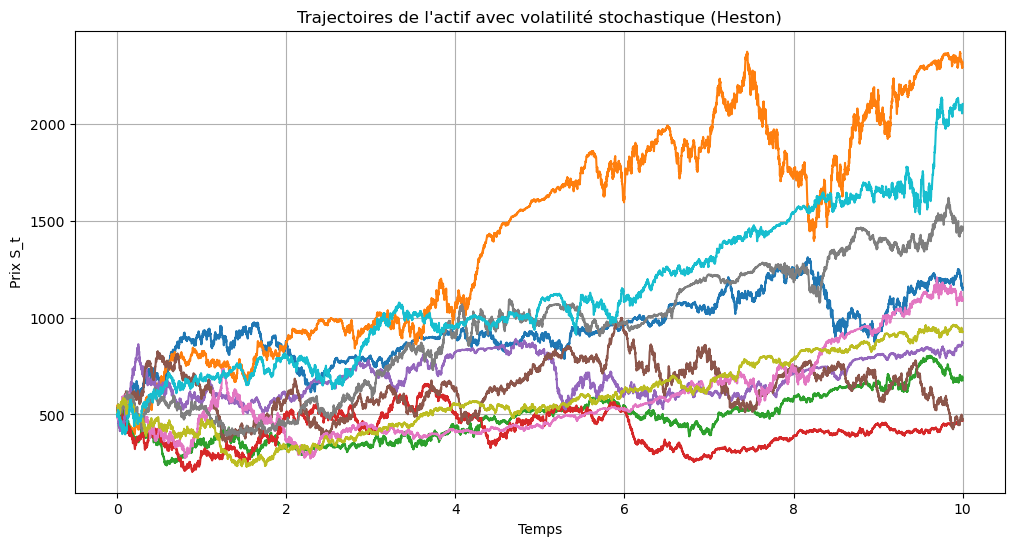

In [328]:
# Paramètres du modèle Heston
S0 = 500       # prix initial de l'actif
v0 = 0.25     # variance initiale
mu = 0.05      # drift de l'actif
kappa = 1.0    # vitesse de réversion variance
theta = 0.04   # niveau moyen variance
sigma = 0.3    # volatilité de la variance
rho = -0.7     # corrélation entre dW_S et dW_v

T = 10          # horizon en années
dt = 0.001
N = int(T/dt)
M = 10          # nombre de trajectoires

# Initialisation
S = np.zeros((M, N+1))
v = np.zeros((M, N+1))
S[:,0] = S0
v[:,0] = v0
t = np.linspace(0, T, N+1)

# Simulation
for i in range(N):
    Z1 = np.random.randn(M)
    Z2 = np.random.randn(M)
    dW_v = np.sqrt(dt) * Z1
    dW_S = np.sqrt(dt) * (rho*Z1 + np.sqrt(1-rho**2)*Z2)
    
    # Variance (CIR-like)
    v[:,i+1] = np.abs(v[:,i] + kappa*(theta - v[:,i])*dt + sigma*np.sqrt(v[:,i])*dW_v)
    
    # Actif
    S[:,i+1] = S[:,i] + mu*S[:,i]*dt + np.sqrt(v[:,i])*S[:,i]*dW_S

# Tracé
plt.figure(figsize=(12,6))
for m in range(M):
    plt.plot(t, S[m])
plt.title("Trajectoires de l'actif avec volatilité stochastique (Heston)")
plt.xlabel("Temps")
plt.ylabel("Prix S_t")
plt.grid(True)
plt.show()

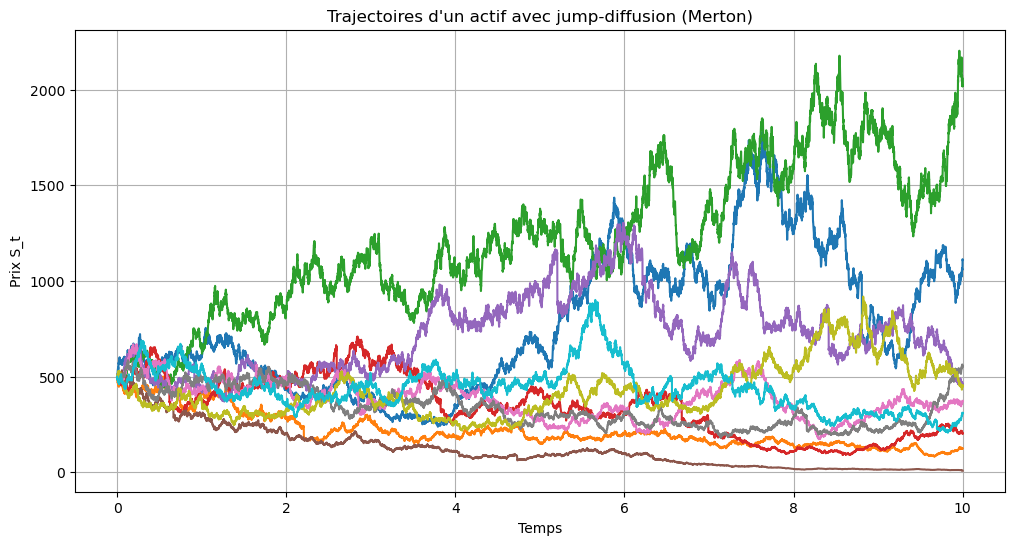

In [329]:
# Paramètres du modèle
S0 = 500       # prix initial
mu = 0.05      # drift
sigma = 0.35    # volatilité
T = 10       # horizon
dt = 0.001
N = int(T/dt)
M = 10          # nombre de trajectoires

# Paramètres des sauts
lambda_jump = 0.3   # intensité de Poisson
mu_J = -0.2         # moyenne du saut log
sigma_J = 0.1       # volatilité du saut

# Initialisation
S = np.zeros((M, N+1))
S[:,0] = S0
t = np.linspace(0, T, N+1)

# Simulation
for i in range(N):
    dW = np.sqrt(dt) * np.random.randn(M)
    # nombre de sauts pour chaque trajectoire dans ce dt
    jumps = np.random.poisson(lambda_jump*dt, size=M)
    # taille du saut
    Y = np.exp(mu_J + sigma_J*np.random.randn(M)) * jumps + (jumps==0)
    
    # évolution du prix
    S[:,i+1] = S[:,i] + mu*S[:,i]*dt + sigma*S[:,i]*dW
    S[:,i+1] *= Y  # appliquer le saut

# Tracé
plt.figure(figsize=(12,6))
for m in range(M):
    plt.plot(t, S[m])
plt.title("Trajectoires d'un actif avec jump-diffusion (Merton)")
plt.xlabel("Temps")
plt.ylabel("Prix S_t")
plt.grid(True)
plt.show()

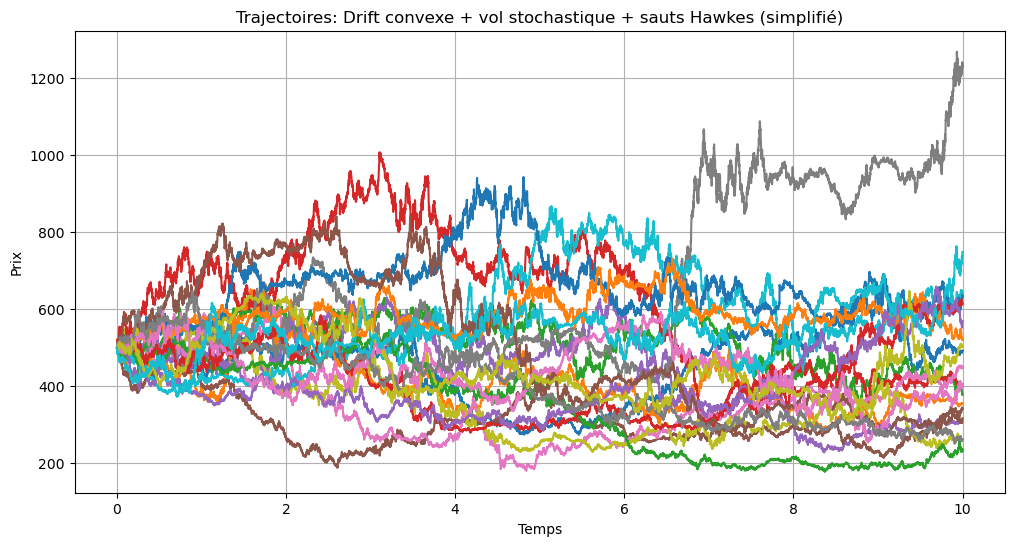

In [330]:
# Paramètres de l'actif
S0 = 500
T = 10
dt = 0.001
N = int(T/dt)
M = 20  # trajectoires

# Drift convexe
a, b, c = 0.01, 0.05, 0.2

# Vol stochastique (CIR)
v0, kappa, theta, sigma_v = 0.04, 2.0, 0.04, 0.3

# Hawkes jump parameters
lambda0 = 0.1
alpha = 0.5
beta = 3.0
mu_J, sigma_J = 0.02, 0.05  # jump size

# Initialisation
S = np.zeros((M, N+1))
v = np.zeros((M, N+1))
lambda_t = np.zeros((M, N+1))
S[:,0] = S0
v[:,0] = v0
lambda_t[:,0] = lambda0
t = np.linspace(0, T, N+1)

for i in range(N):
    # Drift convexe
    drift = a + b*t[i] + c*t[i]**2
    
    # Vol stochastique
    dW_v = np.sqrt(dt) * np.random.randn(M)
    v[:,i+1] = np.abs(v[:,i] + kappa*(theta - v[:,i])*dt + sigma_v*np.sqrt(v[:,i])*dW_v)
    
    # Brownian motion pour l'actif
    dW_S = np.sqrt(dt) * np.random.randn(M)
    
    # Hawkes jump: intensité dépend des sauts précédents
    lambda_t[:,i+1] = lambda0 + (lambda_t[:,i] - lambda0)*np.exp(-beta*dt) + alpha * (S[:,i] != S[:,i])  # simplification
    
    # Nombre de sauts (Poisson)
    jumps = np.random.poisson(lambda_t[:,i+1]*dt)
    
    # Taille des sauts
    Y = 1 + np.random.normal(mu_J, sigma_J, M) * jumps
    
    # Mise à jour prix
    S[:,i+1] = S[:,i] + drift*dt + np.sqrt(v[:,i])*S[:,i]*dW_S
    S[:,i+1] *= Y

# Tracé
plt.figure(figsize=(12,6))
for m in range(M):
    plt.plot(t, S[m])
plt.title("Trajectoires: Drift convexe + vol stochastique + sauts Hawkes (simplifié)")
plt.xlabel("Temps")
plt.ylabel("Prix")
plt.grid(True)
plt.show()

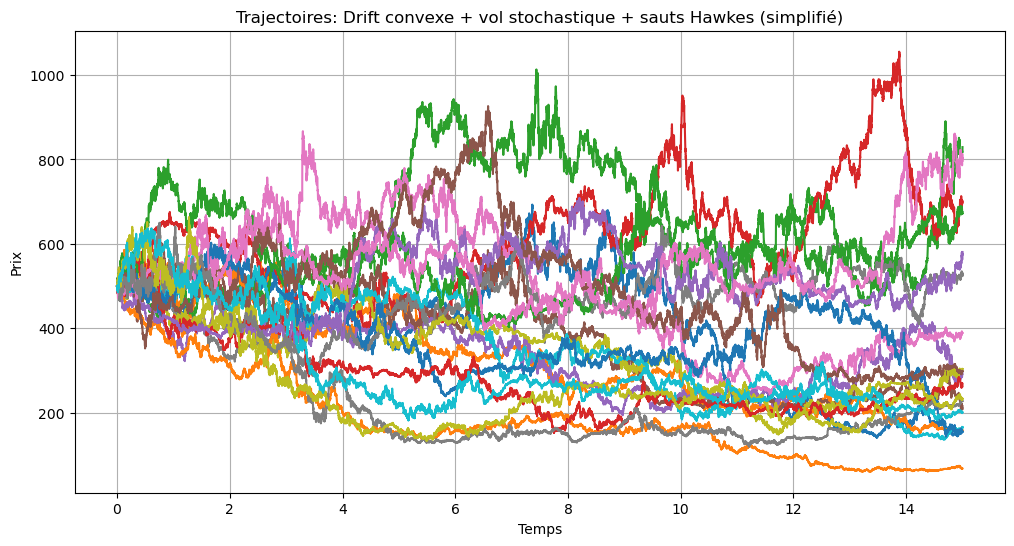

In [331]:
# Paramètres de l'actif
S0 = 500
T = 15
dt = 0.001
N = int(T/dt)
M = 20  # trajectoires

# Drift convexe
a, b, c = 0.01, 0.05, 0.2

# Vol stochastique (CIR)
v0, kappa, theta, sigma_v = 0.04, 2.0, 0.04, 0.3

# Hawkes jump parameters
lambda0 = 0.1
alpha = 0.5
beta = 3.0
mu_J, sigma_J = 0.02, 0.05  # jump size

# Initialisation
S = np.zeros((M, N+1))
v = np.zeros((M, N+1))
lambda_t = np.zeros((M, N+1))
S[:,0] = S0
v[:,0] = v0
lambda_t[:,0] = lambda0
t = np.linspace(0, T, N+1)

for i in range(N):
    # Drift convexe
    drift = np.exp(a + b*t[i])
    
    # Vol stochastique
    dW_v = np.sqrt(dt) * np.random.randn(M)
    v[:,i+1] = np.abs(v[:,i] + kappa*(theta - v[:,i])*dt + sigma_v*np.sqrt(v[:,i])*dW_v)
    
    # Brownian motion pour l'actif
    dW_S = np.sqrt(dt) * np.random.randn(M)
    
    # Hawkes jump: intensité dépend des sauts précédents
    lambda_t[:,i+1] = lambda0 + (lambda_t[:,i] - lambda0)*np.exp(-beta*dt) + alpha * (S[:,i] != S[:,i])  # simplification
    
    # Nombre de sauts (Poisson)
    jumps = np.random.poisson(lambda_t[:,i+1]*dt)
    
    # Taille des sauts
    Y = 1 + np.random.normal(mu_J, sigma_J, M) * jumps
    
    # Mise à jour prix
    S[:,i+1] = S[:,i] + drift*dt + np.sqrt(v[:,i])*S[:,i]*dW_S
    S[:,i+1] *= Y

# Tracé
plt.figure(figsize=(12,6))
for m in range(M):
    plt.plot(t, S[m])
plt.title("Trajectoires: Drift convexe + vol stochastique + sauts Hawkes (simplifié)")
plt.xlabel("Temps")
plt.ylabel("Prix")
plt.grid(True)
plt.show()

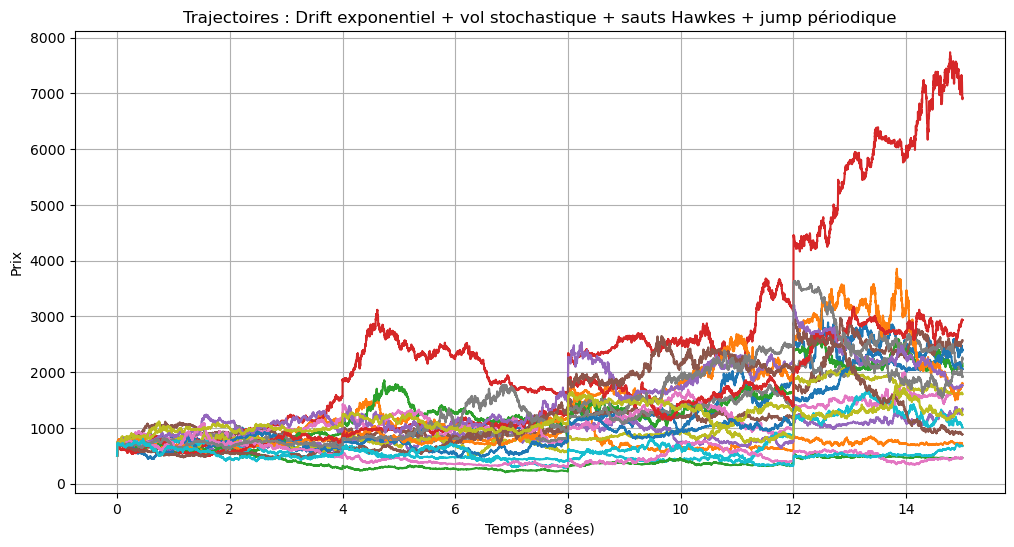

In [332]:
# ----------------------
# Paramètres de simulation
# ----------------------
S0 = 500
T = 15        # années
dt = 0.001
N = int(T/dt)
M = 20        # trajectoires

# Drift exponentiel
a, b = 0.01, 0.05

# Vol stochastique (CIR)
v0, kappa, theta, sigma_v = 0.04, 2.0, 0.04, 0.3

# Hawkes jump parameters
lambda0 = 0.1
alpha = 0.5
beta = 3.0
mu_J, sigma_J = 0.02, 0.05  # jump size

# Jump périodique
jump_period = 4   # en années
jump_mean_factor = 1.2  # on remonte le prix moyen de 20%

# Initialisation
S = np.zeros((M, N+1))
v = np.zeros((M, N+1))
lambda_t = np.zeros((M, N+1))
S[:,0] = S0
v[:,0] = v0
lambda_t[:,0] = lambda0
t = np.linspace(0, T, N+1)

for i in range(N):
    # Drift exponentiel
    drift = np.exp(a + b*t[i])
    
    # Vol stochastique
    dW_v = np.sqrt(dt) * np.random.randn(M)
    v[:,i+1] = np.abs(v[:,i] + kappa*(theta - v[:,i])*dt + sigma_v*np.sqrt(v[:,i])*dW_v)
    
    # Brownian motion pour l'actif
    dW_S = np.sqrt(dt) * np.random.randn(M)
    
    # Hawkes jump simplifié
    lambda_t[:,i+1] = lambda0 + (lambda_t[:,i] - lambda0)*np.exp(-beta*dt)
    jumps = np.random.poisson(lambda_t[:,i+1]*dt)
    Y = 1 + np.random.normal(mu_J, sigma_J, M) * jumps
    
    # Mise à jour prix
    S[:,i+1] = S[:,i] + drift*dt + np.sqrt(v[:,i])*S[:,i]*dW_S
    S[:,i+1] *= Y
    
    # ----------------------
    # Jump périodique tous les 4 ans
    # ----------------------
    if np.isclose(t[i] % jump_period, 0, atol=dt):
        S[:,i+1] *= jump_mean_factor  # reset du prix moyen

# Tracé
plt.figure(figsize=(12,6))
for m in range(M):
    plt.plot(t, S[m])
plt.title("Trajectoires : Drift exponentiel + vol stochastique + sauts Hawkes + jump périodique")
plt.xlabel("Temps (années)")
plt.ylabel("Prix")
plt.grid(True)
plt.show()

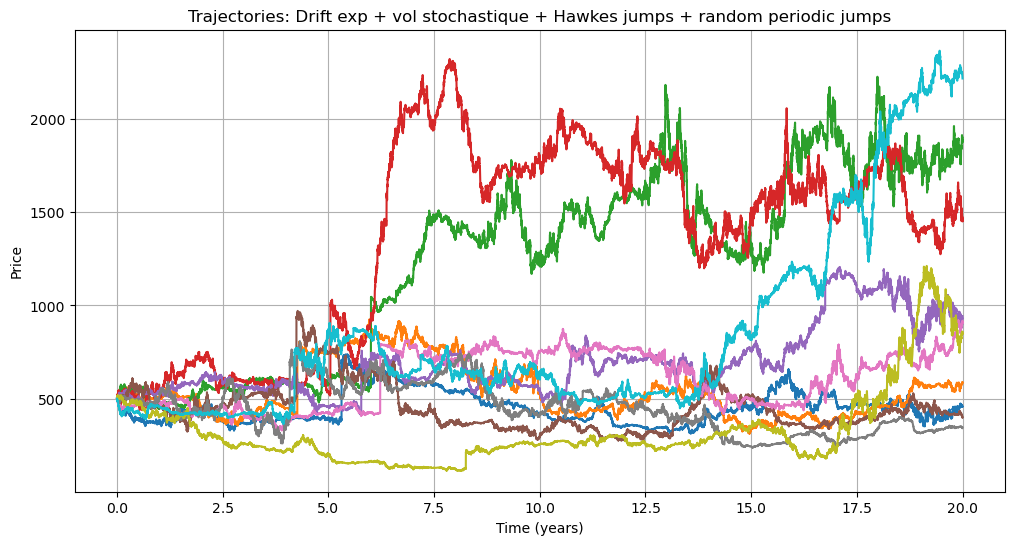

In [373]:
# ----------------------
# Parameters
# ----------------------
S0 = 500
T = 20        # years
dt = 0.001
N = int(T/dt)
M = 10        # trajectories

# Drift exponentiel
a, b = 0.05, 0.2

# Vol stochastique (CIR)
v0, kappa, theta, sigma_v = 0.04, 2.0, 0.04, 0.45

# Hawkes jump parameters
lambda0 = 0.3
alpha = 0.8
beta = 3.0
mu_J, sigma_J = 0.02, 0.05  # jump size

# Periodic jump
jump_period = 4   # every 4 years
jump_mean = 1.8
jump_std = 0.15  # standard deviation around the mean

# Initialization
S = np.zeros((M, N+1))
v = np.zeros((M, N+1))
lambda_t = np.zeros((M, N+1))
S[:,0] = S0
v[:,0] = v0
lambda_t[:,0] = lambda0
t = np.linspace(0, T, N+1)

# ----------------------
# Random jump time after 4 years
# ----------------------
lambda_wait = 1.0  # intensity of waiting time

jump_time = 4 + np.random.exponential(1/lambda_wait, M)
jump_done = np.zeros(M, dtype=bool)

for i in range(N):

    drift = np.exp(a + b*t[i])
    
    dW_v = np.sqrt(dt) * np.random.randn(M)
    v[:,i+1] = np.abs(v[:,i] + kappa*(theta - v[:,i])*dt + sigma_v*np.sqrt(v[:,i])*dW_v)

    dW_S = np.sqrt(dt) * np.random.randn(M)

    # Hawkes
    lambda_t[:,i+1] = lambda0 + (lambda_t[:,i] - lambda0)*np.exp(-beta*dt)
    jumps = np.random.poisson(lambda_t[:,i+1]*dt)
    Y = 1 + np.random.normal(mu_J, sigma_J, M) * jumps

    S[:,i+1] = S[:,i] + drift*dt + np.sqrt(v[:,i])*S[:,i]*dW_S
    S[:,i+1] *= Y

    # ----------------------
    # Random jump after 4 years
    # ----------------------
    for m in range(M):
        if (not jump_done[m]) and (t[i] >= jump_time[m]):
            jump_factor = np.random.normal(jump_mean, jump_std)
            S[m,i+1] *= jump_factor
            jump_done[m] = True

# Plot
plt.figure(figsize=(12,6))
for m in range(M):
    plt.plot(t, S[m])
plt.title("Trajectories: Drift exp + vol stochastique + Hawkes jumps + random periodic jumps")
plt.xlabel("Time (years)")
plt.ylabel("Price")
plt.grid(True) 
plt.show()

## Stats tests

In [374]:
returns = np.diff(np.log(S), axis=1)

In [375]:
r = returns[0]

In [376]:
print("Mean:", r.mean())
print("Std:", r.std())
print("Skewness:", skew(r))
print("Excess Kurtosis:", kurtosis(r))

Mean: -4.284578967547193e-06
Std: 0.007131095137325166
Skewness: 29.68192679691057
Excess Kurtosis: 2478.652810588507


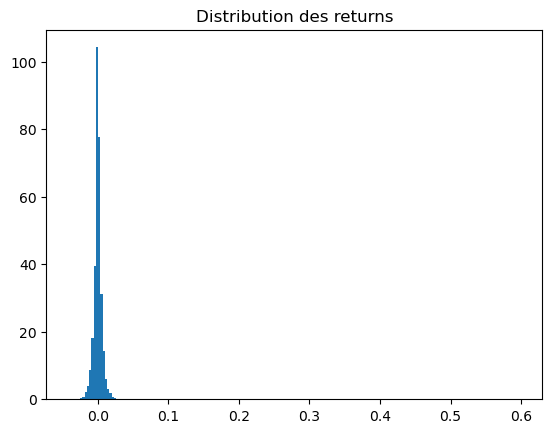

In [377]:
plt.hist(r, bins=200, density=True)
plt.title("Distribution des returns")
plt.show()

In [378]:
jb_stat, jb_p = jarque_bera(r)

print("Jarque-Bera stat:", jb_stat)
print("p-value:", jb_p)

Jarque-Bera stat: 5122703185.459845
p-value: 0.0


In [379]:
print("Skewness:", skew(r))
print("Kurtosis:", kurtosis(r))

Skewness: 29.68192679691057
Kurtosis: 2478.652810588507


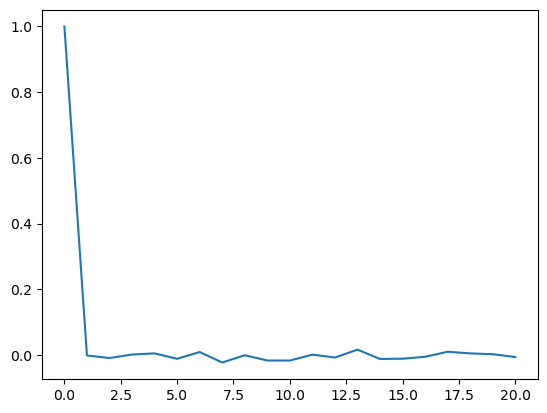

In [380]:
acf_vals = acf(r, nlags=20)

plt.plot(acf_vals)

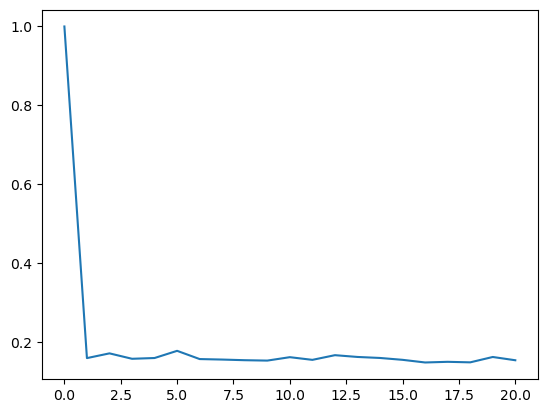

In [381]:
acf_vol = acf(np.abs(r), nlags=20)

plt.plot(acf_vol)

In [382]:
arch_test = het_arch(r)

print("ARCH stat:", arch_test[0])
print("p-value:", arch_test[1])

ARCH stat: 0.14066613424732366
p-value: 0.9999999864735588


In [383]:
adf = adfuller(r)

print("ADF stat:", adf[0])
print("p-value:", adf[1])

ADF stat: -20.696502864040635
p-value: 0.0


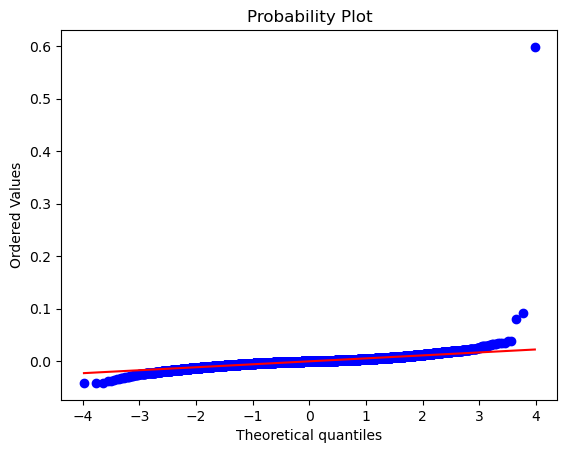

In [384]:
stats.probplot(r, dist="norm", plot=plt)
plt.show()

In [385]:
def hill_estimator(data, k=1000):
    x = np.sort(np.abs(data))
    x = x[-k:]
    x_k = x[0]
    hill = (1/k) * np.sum(np.log(x/x_k))
    return 1/hill

alpha = hill_estimator(r, k=1000)
print("Tail index alpha:", alpha)

Tail index alpha: 3.46232899561578
